<a href="https://colab.research.google.com/github/sakshithapa010-blip/DS_Assignment_3/blob/main/Global_Terrorism_Analysis_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import missingno as msno
%matplotlib inline

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
"""
# PROJECT SUMMARY
This project performs an Exploratory Data Analysis (EDA) on the United Nations Global Terrorism Analysis (UNGTA)
dataset (1970-2017). With over 180,000 records, the project seeks to identify temporal, geographical,
and operational patterns.

# PROBLEM STATEMENT
Terrorist attacks are becoming more complex. The goal is to transform raw data into meaningful insights
to help stakeholders understand the global terrorism landscape, identifying hotspots, common attack
methods, and the severity of impact in terms of casualties.

# BUSINESS OBJECTIVE
1. Analyze trends from 1970–2017.
2. Identify most affected countries and regions.
3. Understand attack types and weapons used.
4. Study casualties and impact to support security decision-making.
"""

'\n# PROJECT SUMMARY\nThis project performs an Exploratory Data Analysis (EDA) on the United Nations Global Terrorism Analysis (UNGTA) \ndataset (1970-2017). With over 180,000 records, the project seeks to identify temporal, geographical, \nand operational patterns.\n\n# PROBLEM STATEMENT\nTerrorist attacks are becoming more complex. The goal is to transform raw data into meaningful insights \nto help stakeholders understand the global terrorism landscape, identifying hotspots, common attack \nmethods, and the severity of impact in terms of casualties.\n\n# BUSINESS OBJECTIVE\n1. Analyze trends from 1970–2017.\n2. Identify most affected countries and regions.\n3. Understand attack types and weapons used.\n4. Study casualties and impact to support security decision-making.\n'

In [ ]:
# Loading the dataset with specific encoding for GTD
try:
    df = pd.read_csv('Global Terrorism Data.csv', encoding='latin1', low_memory=False)
    print("Dataset loaded successfully!")
except:
    print("Error: Ensure 'Global Terrorism Data.csv' is uploaded to the root directory.")

# Basic Inspection
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (181691, 135)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [ ]:
# Selecting and Renaming key columns for readability (Matches the 'extra info' structure)
df = df.rename(columns={'iyear':'Year','imonth':'Month','iday':'Day','country_txt':'Country',
                       'region_txt':'Region','attacktype1_txt':'AttackType','target1':'Target',
                       'nkill':'Killed','nwound':'Wounded','gname':'Group',
                       'targtype1_txt':'Target_type','weaptype1_txt':'Weapon_type'})

# Keep only the relevant columns
df = df[['Year','Month','Day','Country','Region','city','latitude','longitude',
         'AttackType','Killed','Wounded','Target','Group','Target_type','Weapon_type']]

# Handling Missing Values (Essential for Casualty Analysis)
df['Killed'] = df['Killed'].fillna(0).astype(int)
df['Wounded'] = df['Wounded'].fillna(0).astype(int)
df['Casualties'] = df['Killed'] + df['Wounded']

print("Data Wrangling Complete.")
df.info()

Data Wrangling Complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Year         181691 non-null  int64  
 1   Month        181691 non-null  int64  
 2   Day          181691 non-null  int64  
 3   Country      181691 non-null  object 
 4   Region       181691 non-null  object 
 5   city         181256 non-null  object 
 6   latitude     177135 non-null  float64
 7   longitude    177134 non-null  float64
 8   AttackType   181691 non-null  object 
 9   Killed       181691 non-null  int64  
 10  Wounded      181691 non-null  int64  
 11  Target       181053 non-null  object 
 12  Group        181691 non-null  object 
 13  Target_type  181691 non-null  object 
 14  Weapon_type  181691 non-null  object 
 15  Casualties   181691 non-null  int64  
dtypes: float64(2), int64(6), object(8)
memory usage: 22.2+ MB


<Figure size 1000x500 with 0 Axes>

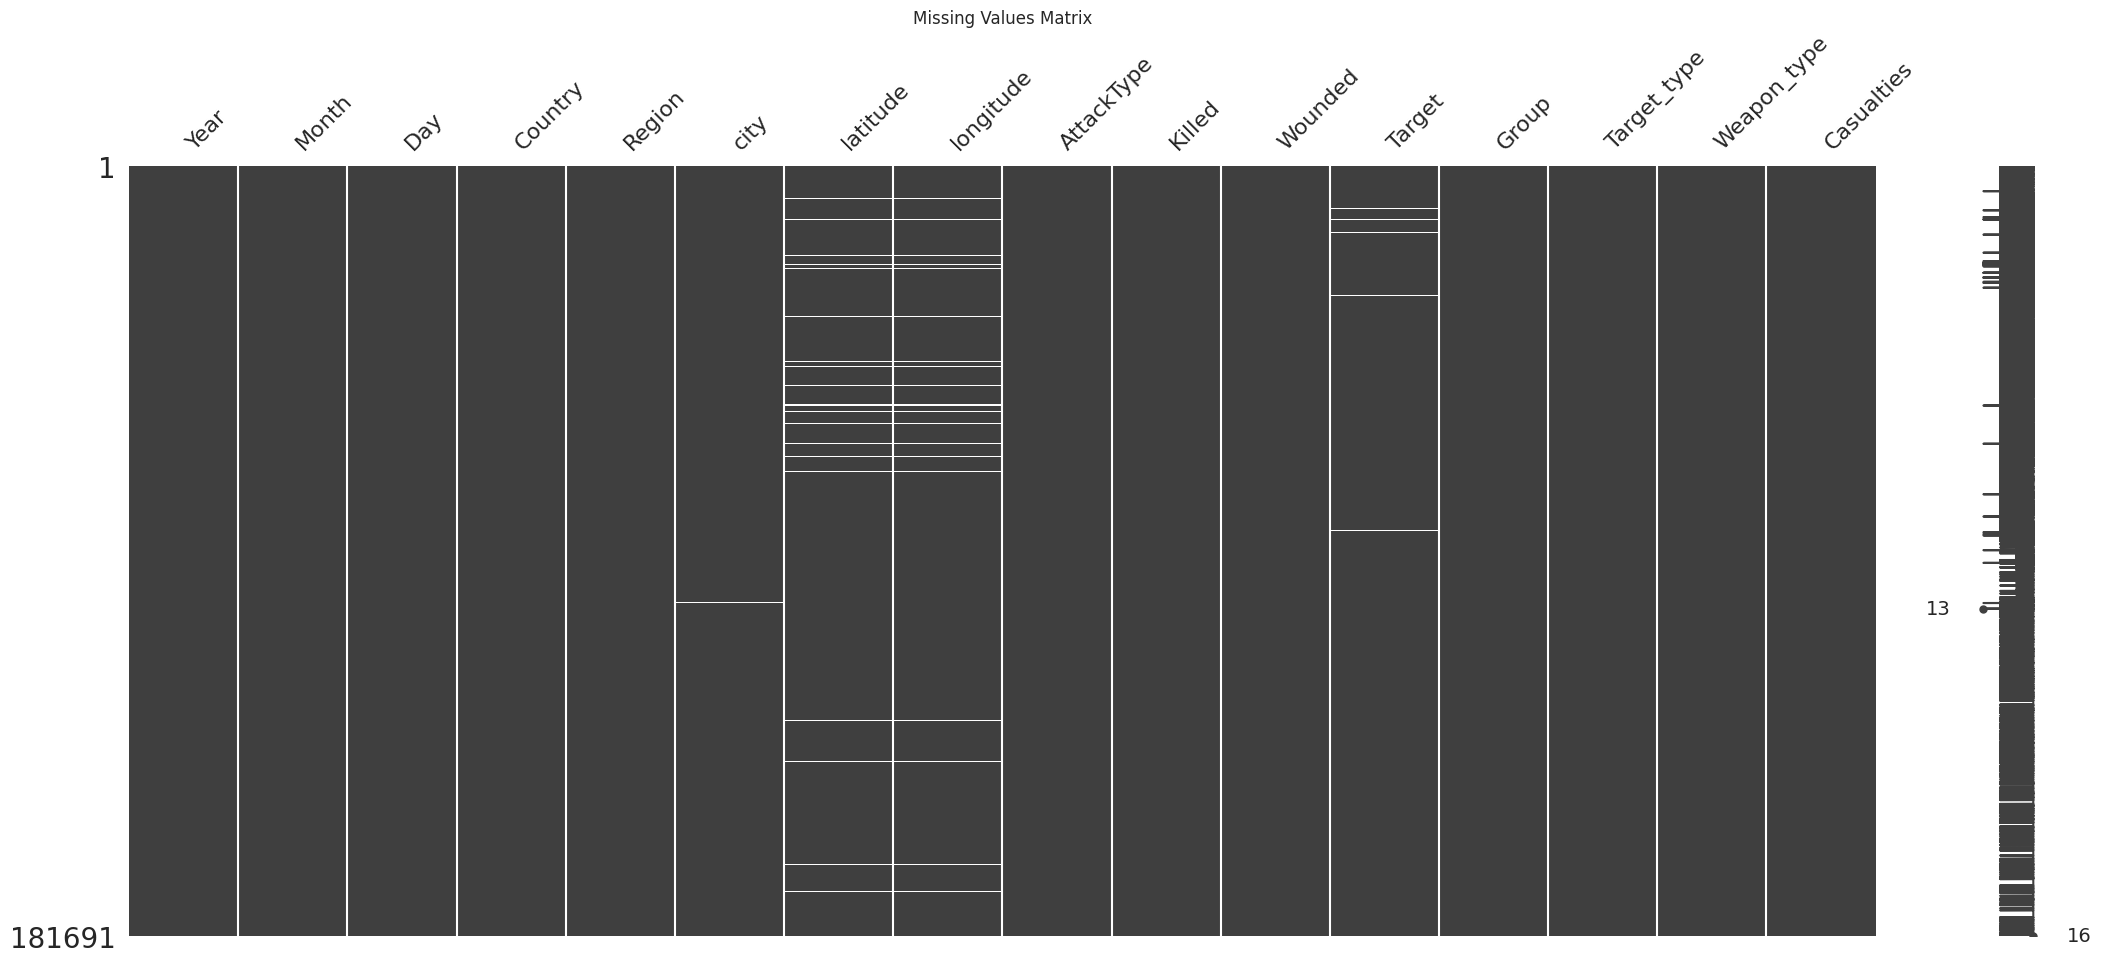

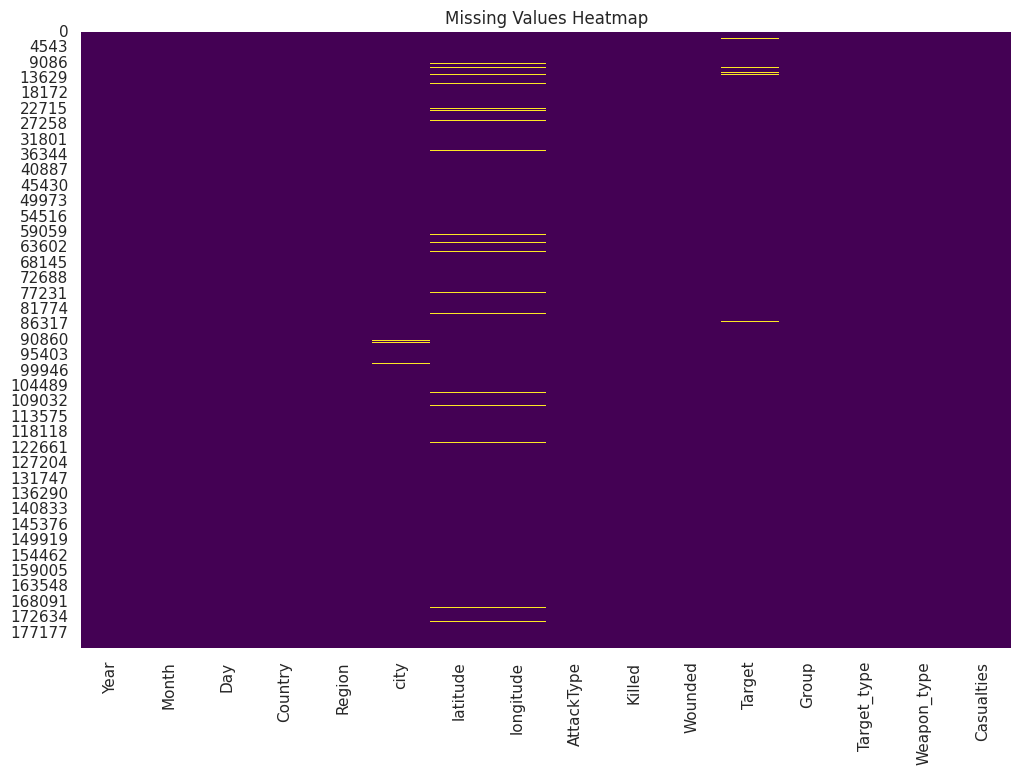

In [ ]:
# Visualizing missing data patterns
plt.figure(figsize=(10, 5))
msno.matrix(df)
plt.title("Missing Values Matrix")
plt.show()

# Heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

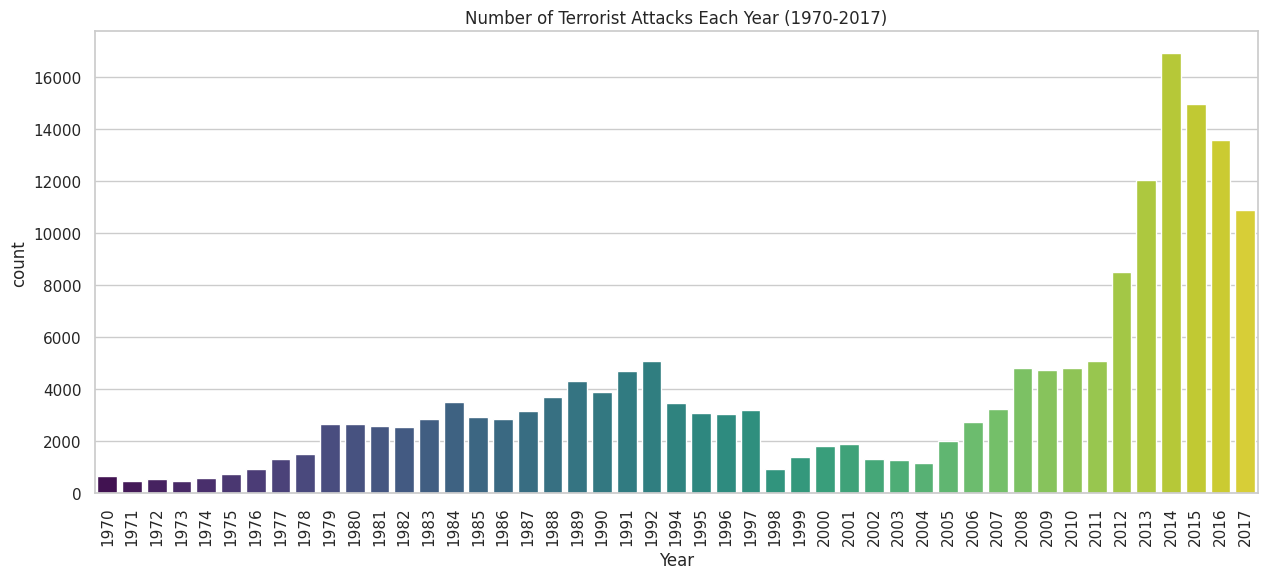

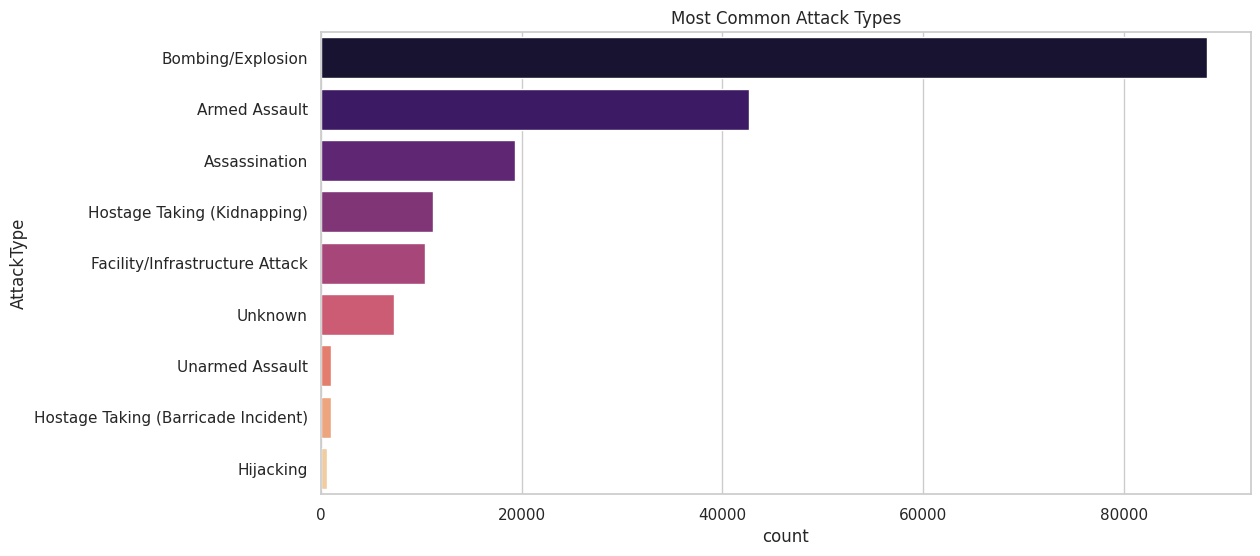

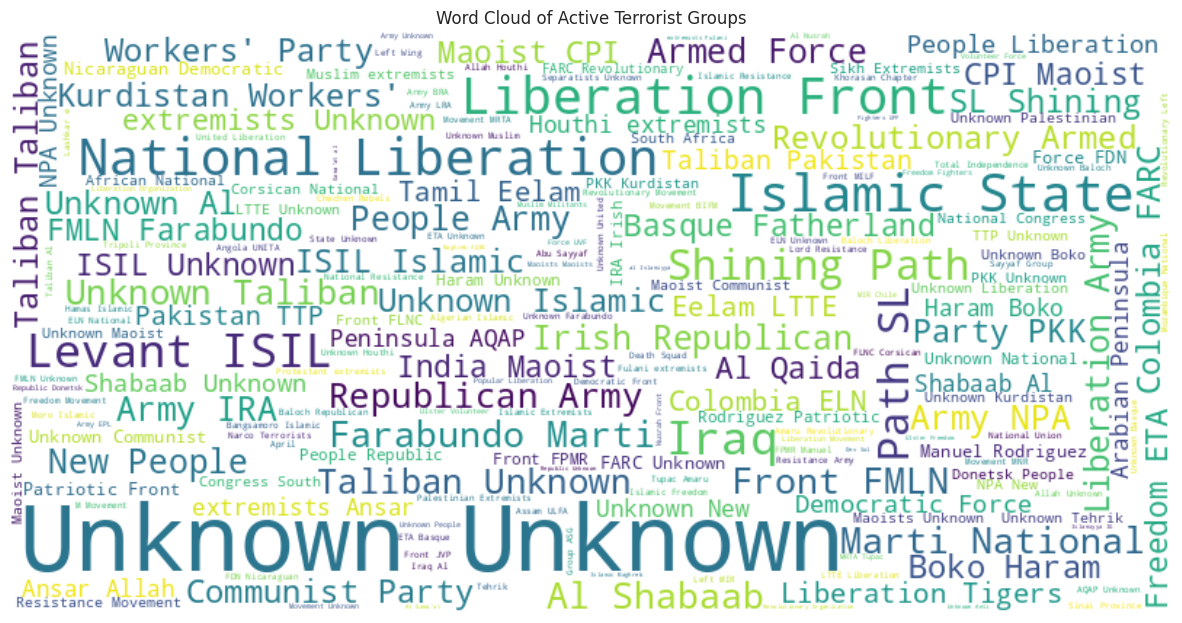

In [ ]:
# 1. Yearly Trend (Bar Chart)
plt.figure(figsize=(15,6))
sns.countplot(x='Year', data=df, palette='viridis')
plt.xticks(rotation=90)
plt.title('Number of Terrorist Attacks Each Year (1970-2017)')
plt.show()

# 2. Most Common Attack Types (Horizontal Bar)
plt.figure(figsize=(12,6))
sns.countplot(y='AttackType', data=df, order=df['AttackType'].value_counts().index, palette='magma')
plt.title('Most Common Attack Types')
plt.show()

# 3. Word Cloud of Terrorist Groups (Advanced Visualization)
groups = df['Group'].dropna()
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(groups))
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Active Terrorist Groups")
plt.show()

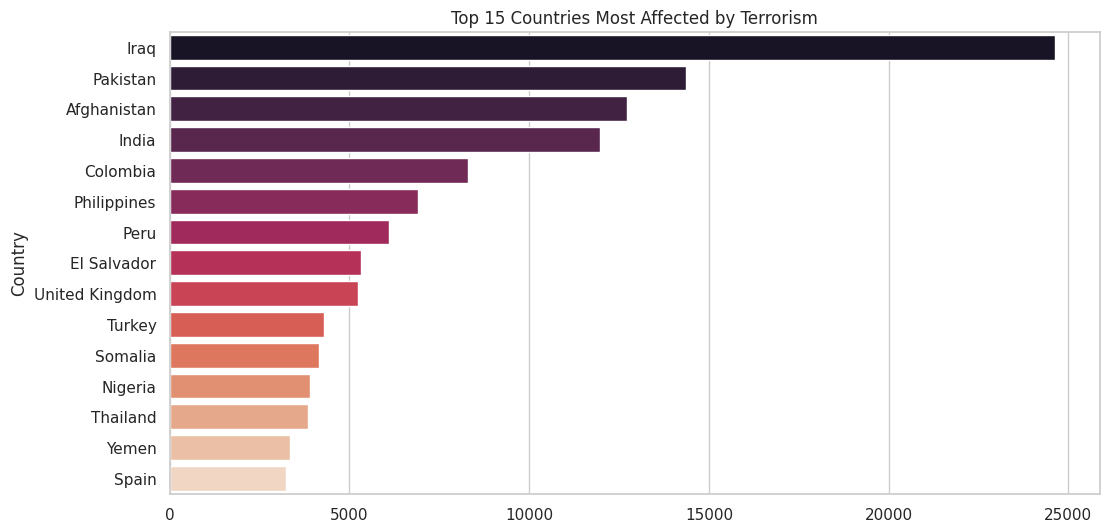

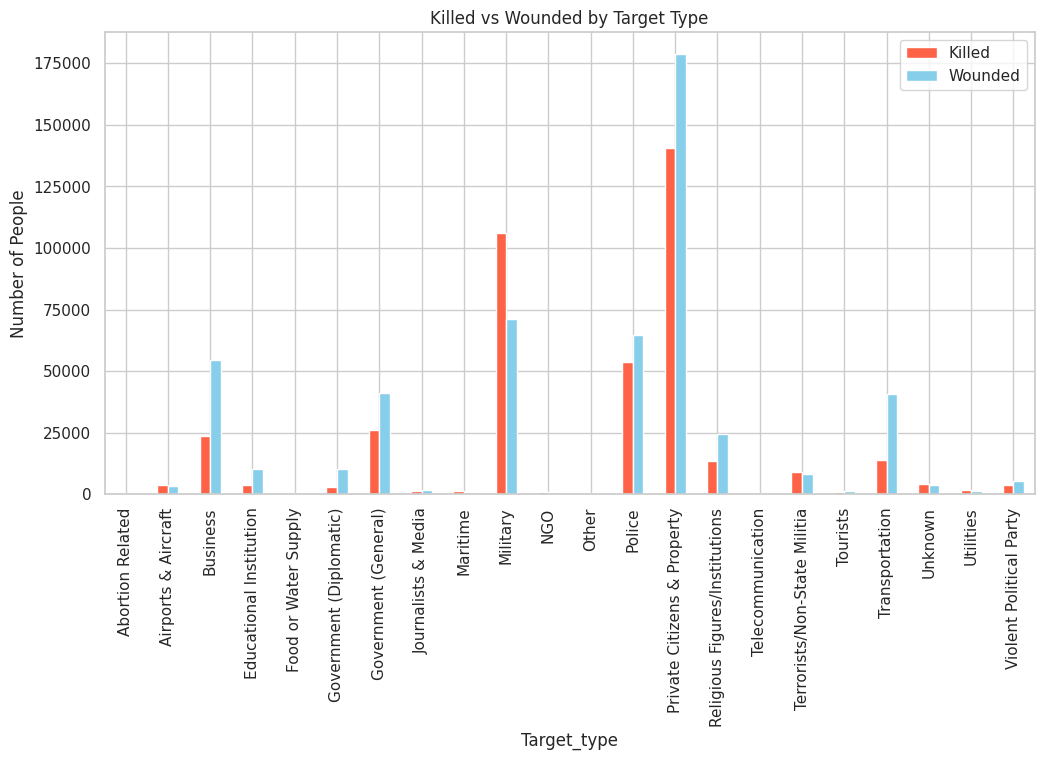

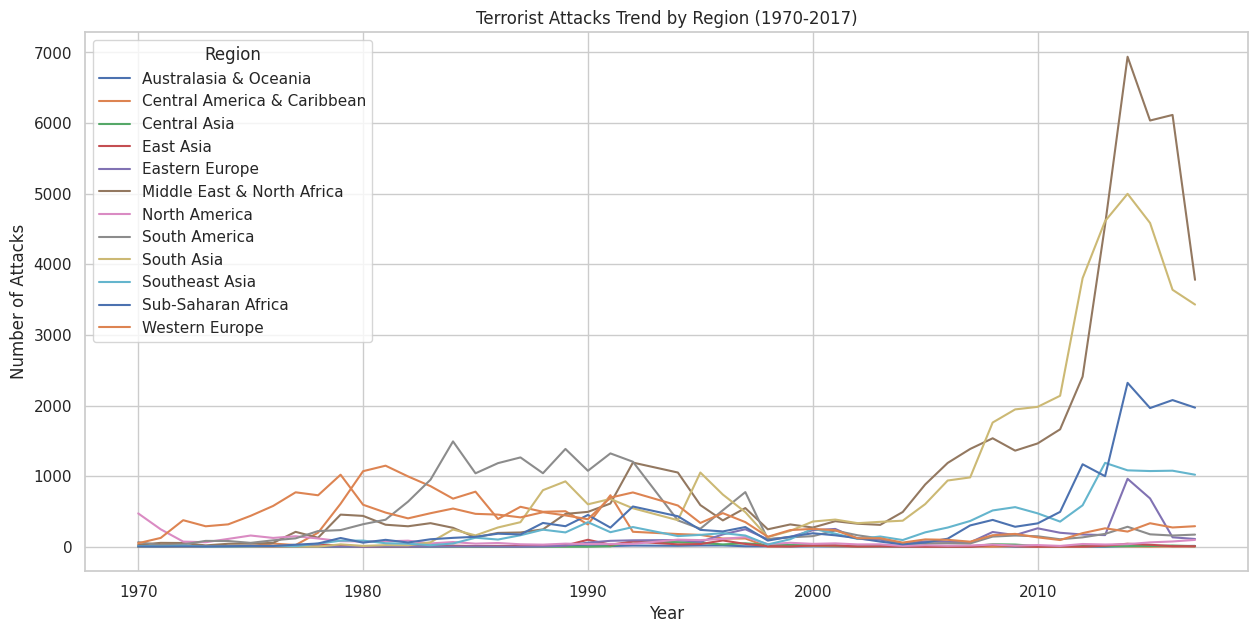

In [ ]:
# 1. Top 15 Countries Affected
top_countries = df['Country'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket')
plt.title('Top 15 Countries Most Affected by Terrorism')
plt.show()

# 2. Killed vs Wounded by Target Type
target_stats = df.groupby('Target_type')[['Killed', 'Wounded']].sum()
target_stats.plot(kind='bar', stacked=False, color=['tomato', 'skyblue'], figsize=(12,6))
plt.title('Killed vs Wounded by Target Type')
plt.ylabel('Number of People')
plt.show()

# 3. Attacks in Different Regions Over Time (Crosstab Logic)
region_year = pd.crosstab(df.Year, df.Region)
region_year.plot(figsize=(15,7))
plt.title('Terrorist Attacks Trend by Region (1970-2017)')
plt.ylabel('Number of Attacks')
plt.show()

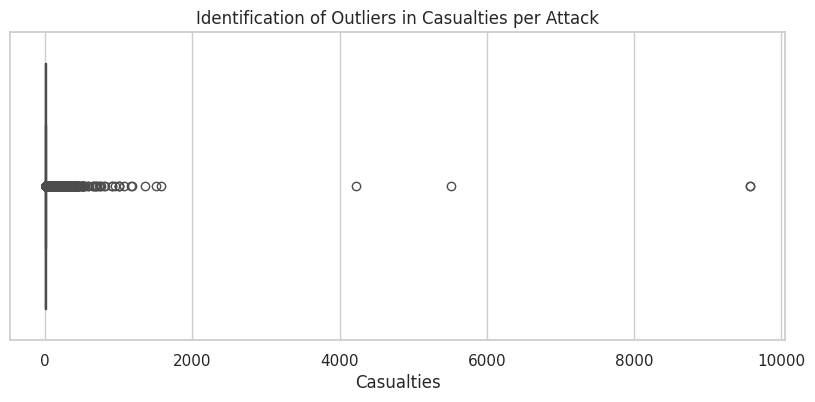

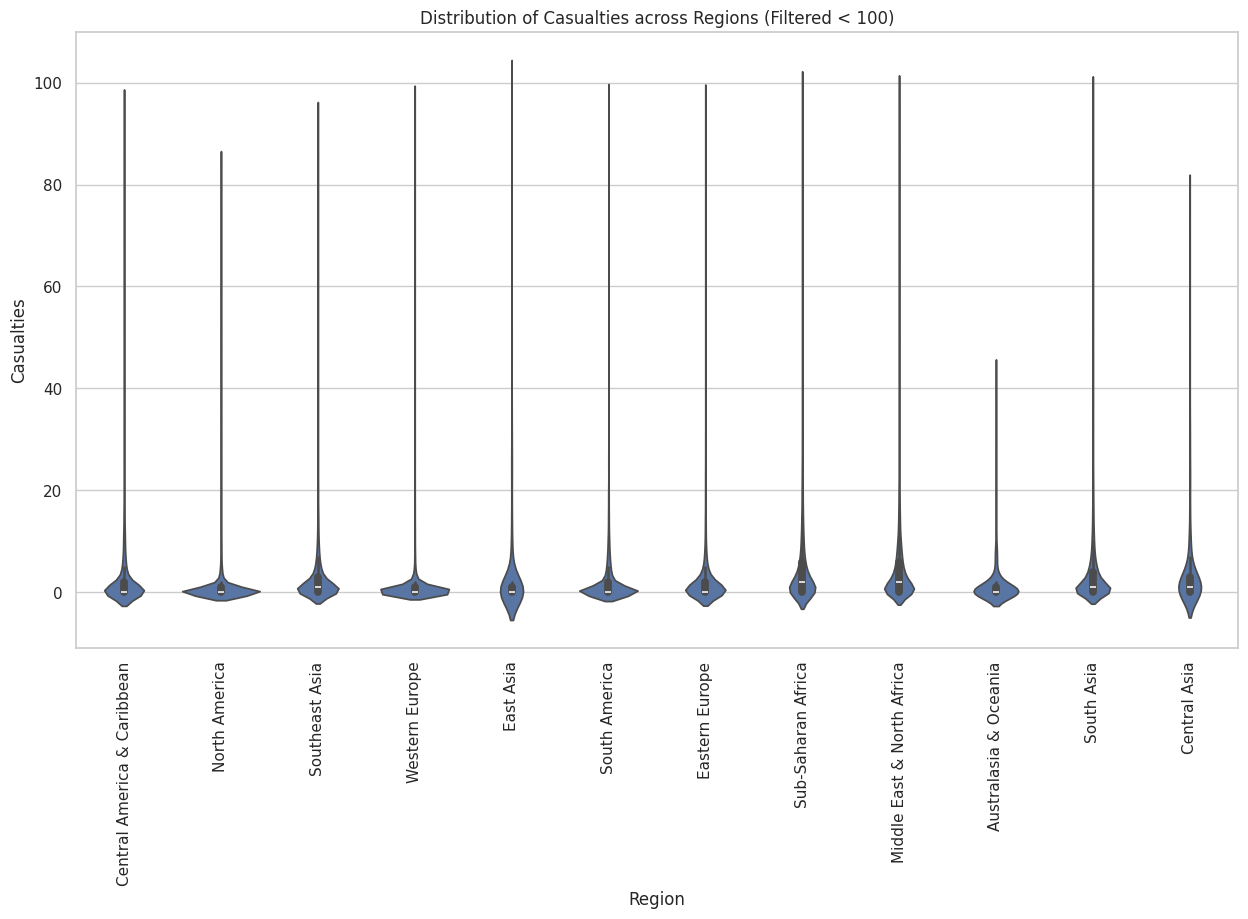

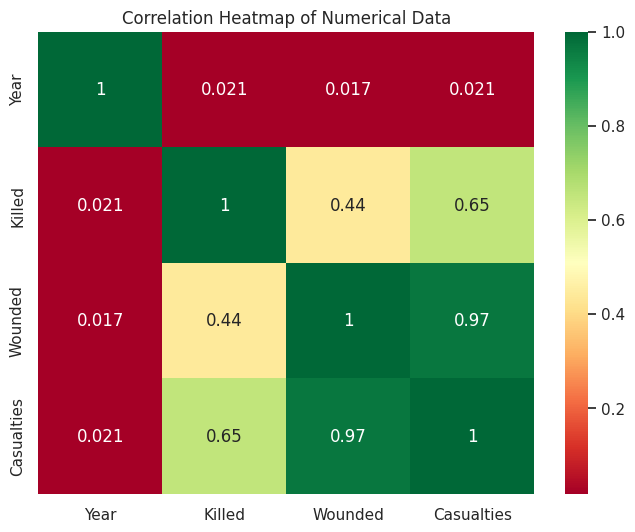

In [ ]:
# 1. Outlier Detection in Casualties (Boxplot from uploaded version)
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Casualties'], color='orange')
plt.title('Identification of Outliers in Casualties per Attack')
plt.show()

# 2. Distribution of Casualties by Region (Violin Plot)
# Filter for better visualization (excluding massive outliers)
temp_df = df[df['Casualties'] < 100]
plt.figure(figsize=(15, 8))
sns.violinplot(x='Region', y='Casualties', data=temp_df)
plt.xticks(rotation=90)
plt.title('Distribution of Casualties across Regions (Filtered < 100)')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Year', 'Killed', 'Wounded', 'Casualties']].corr(), annot=True, cmap='RdYlGn')
plt.title("Correlation Heatmap of Numerical Data")
plt.show()

In [ ]:
"""
# FINAL INSIGHTS & SOLUTIONS
1. **Temporal Peak**: Terrorism spiked globally after 2010, peaking around 2014-2015.
2. **Regional Hotspots**: The Middle East, North Africa, and South Asia remain the most volatile regions.
3. **Primary Methods**: Explosives/Bombings are the most lethal and frequent; security should focus on explosive detection.
4. **Target Strategy**: Civilians are the most frequent targets, suggesting a need for better urban surveillance.
5. **Group Activity**: A small number of groups are responsible for a large percentage of total casualties.

# CONCLUSION
The analysis successfully identifies critical patterns in global terrorism. This data-driven approach
allows for more efficient resource allocation for international security agencies and provides a
clear roadmap for regional counter-terrorism efforts.
"""

'\n# FINAL INSIGHTS & SOLUTIONS\n1. **Temporal Peak**: Terrorism spiked globally after 2010, peaking around 2014-2015.\n2. **Regional Hotspots**: The Middle East, North Africa, and South Asia remain the most volatile regions.\n3. **Primary Methods**: Explosives/Bombings are the most lethal and frequent; security should focus on explosive detection.\n4. **Target Strategy**: Civilians are the most frequent targets, suggesting a need for better urban surveillance.\n5. **Group Activity**: A small number of groups are responsible for a large percentage of total casualties.\n\n# CONCLUSION\nThe analysis successfully identifies critical patterns in global terrorism. This data-driven approach \nallows for more efficient resource allocation for international security agencies and provides a \nclear roadmap for regional counter-terrorism efforts.\n'

In [1]:
# ==========================================
# SUBMISSION DETAILS
# ==========================================
print("Project Completed Successfully")
print("-" * 30)
print("Submitted By:Sakshi Thapa")
print("B.Tech (CSE)")
print("Roll No: 2472118")
print("College Name : Doon University")
print("-" * 30)

Project Completed Successfully
------------------------------
Submitted By:Sakshi Thapa
B.Tech (CSE)
Roll No: 2472118
College Name : Doon University
------------------------------
